# Paper figures for `pool_x_selector`

Run cells top-to-bottom **after** the production sweep finishes.

Each cell is **standalone** and starts with a header comment stating:
  - **CLAIM**: the one distinct paper claim it supports.
  - **DATA**: the on-disk path glob it reads.
  - **USES**: the helper functions it imports.

Outputs (PNG figures + Markdown/LaTeX tables) are written to:
`results/aggregate/figures/paper/`.

> **Performance note.** Cell 0 does ALL imports (incl. the heavy upstream
> chain) ONCE. Downstream cells do NOT reload modules — that was the
> 10-minute slowdown. If you edit `paper_data.py`, set `RELOAD = True` in
> Cell 0 and re-run only Cell 0; the figure/table cells stay fast.


In [1]:
# ---- Cell 0: setup (run ONCE per session) ----
# CLAIM: imports + path setup; cheap downstream cells.
# DATA : n/a (defines RUNS for downstream cells).
# USES : paper_data, nb_plot.

# Set RELOAD=True ONLY when you've edited paper_data.py / nb_plot.py and
# want the notebook to pick up the changes. Default False keeps cell runs
# fast (no re-traversal of the upstream import chain on Weka).
RELOAD = False

import sys, pathlib, importlib
REPO_ROOT = pathlib.Path('/weka/s226137394/DmNfull')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from Equivariant_pathway.equivariant_CNN_hybrid.baseline_vs_p4.pool_x_selector import (
    paper_data, nb_plot,
)
if RELOAD:
    importlib.reload(paper_data); importlib.reload(nb_plot)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import json
try:
    from IPython.display import display
except ImportError:
    def display(x): print(x)

RUNS = paper_data.available_runs()
print('Discovered runs :', RUNS)
print('Methods         :', paper_data.METHODS)
print('Paper figs dir  :', paper_data.PAPER_FIG_ROOT)


Discovered runs : [1, 10, 2, 3, 4, 5, 6, 7, 8, 9]
Methods         : ('baseline_highloss_fixed', 'baseline_random_fixed', 'baseline_highloss_rotate', 'baseline_random_rotate', 'p4_top3_fixed', 'p4_top3_rotate', 'p4_all_fixed', 'p4_all_rotate')
Paper figs dir  : /weka/s226137394/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/pool_x_selector/results/aggregate/figures/paper


In [ ]:
# ---- Cell 1: F1 headline ----
# CLAIM: sample efficiency, P4-LLM vs the 5 IIL baselines (mean +/- std).
# DATA : results/run_*/<method>/results/learning_curve.json
# USES : nb_plot.compare (palette + 'P4-LLM' relabel come from nb_plot).
METHODS = paper_data.METHODS  # 6-method comparison: 5 IIL baselines + P4-LLM

fig = nb_plot.compare(*METHODS, show_runs=False, figsize=(9, 5))
paper_data.save_figure(fig, 'F1_headline_sr_vs_demos')


In [7]:
# ---- Cell 2: T1 final-SR table ----
# CLAIM: per-method aggregate (final SR, extras-to-target, stopped-reason counts).
# DATA : results/run_*/<method>/results/learning_curve.json (last history entry)
#        + results/run_*/run_summary.json (stopped_reason).
# USES : paper_data.final_sr_dataframe + save_table.
df = paper_data.final_sr_dataframe()
if df.empty:
    print('No learning_curve.json files on disk yet.')
else:
    agg = df.groupby('method', as_index=False).agg(
        n_runs=('run', 'count'),
        final_sr_mean=('final_sr', 'mean'),
        final_sr_std=('final_sr', 'std'),
        final_extras_mean=('final_extras', 'mean'),
        extras_to_target_min=('extras_to_target', 'min'),
        extras_to_target_mean=('extras_to_target', 'mean'),
    ).round(3)
    reasons = (df.groupby(['method', 'stopped_reason']).size()
                 .unstack(fill_value=0).reset_index())
    agg = agg.merge(reasons, on='method', how='left')
    agg['method'] = pd.Categorical(agg['method'], categories=list(paper_data.METHODS), ordered=True)
    agg = agg.sort_values('method').reset_index(drop=True)
    display(agg)
    paths = paper_data.save_table(
        agg, 'T1_final_sr_per_method',
        caption='T1: per-method aggregate final held-out SR, extras-to-target, and stopped-reason counts.',
    )
    print('wrote', paths)


,method,n_runs,final_sr_mean,final_sr_std,final_extras_mean,extras_to_target_min,extras_to_target_mean,budget_exhausted,no_new_demos,pool_solved,target_hit
0,baseline_highloss_fixed,10,0.782,0.063,6.8,NaN,NaN,0,10,0,0
1,baseline_random_fixed,10,0.799,0.049,7.3,NaN,NaN,0,10,0,0
2,baseline_highloss_rotate,10,0.870,0.033,14.9,13.0,14.500,1,2,0,7
3,baseline_random_rotate,10,0.851,0.043,14.9,15.0,15.000,1,4,0,5
4,p4_top3_fixed,10,0.809,0.040,7.9,NaN,NaN,0,0,10,0
5,p4_top3_rotate,10,0.896,0.019,12.6,10.0,11.571,3,0,0,7
6,p4_all_fixed,10,0.792,0.045,7.3,NaN,NaN,0,0,10,0
7,p4_all_rotate,10,0.878,0.025,14.0,11.0,11.667,7,0,0,3


wrote (PosixPath('/weka/s226137394/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/pool_x_selector/results/aggregate/figures/paper/T1_final_sr_per_method.md'), PosixPath('/weka/s226137394/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/pool_x_selector/results/aggregate/figures/paper/T1_final_sr_per_method.tex'))


In [ ]:
# ---- Cell 3: F3 info-gain distribution ----
# CLAIM: P4-LLM selects more informative demos than the IIL baselines (higher
#        pre-finetune policy loss on the chosen/prescribed layout).
# DATA : results/run_*/<method>/results/round_*/prescribed_loss.json
# USES : paper_data.iter_prescribed_losses.
METHODS = paper_data.METHODS

rows = []
for m in METHODS:
    for r in paper_data.iter_prescribed_losses(m):
        rows.append({'method': m, 'policy_loss': r['policy_loss']})
df = pd.DataFrame(rows)
if df.empty:
    print('No prescribed_loss.json files on disk yet.')
else:
    present = [m for m in METHODS if (df.method == m).any()]
    data = [df[df.method == m]['policy_loss'].values for m in present]
    fig, ax = plt.subplots(figsize=(10, 4.8))
    ax.boxplot(data, showfliers=True, vert=True)
    ax.set_xticks(range(1, len(present) + 1))
    ax.set_xticklabels([nb_plot.LABELS.get(m, m) for m in present], rotation=30, ha='right')
    ax.set_ylabel('pre-finetune policy loss on chosen/prescribed demo')
    ax.set_title('F3: information-gain proxy (higher = more informative demo)')
    fig.tight_layout()
    paper_data.save_figure(fig, 'F3_info_gain_distribution')


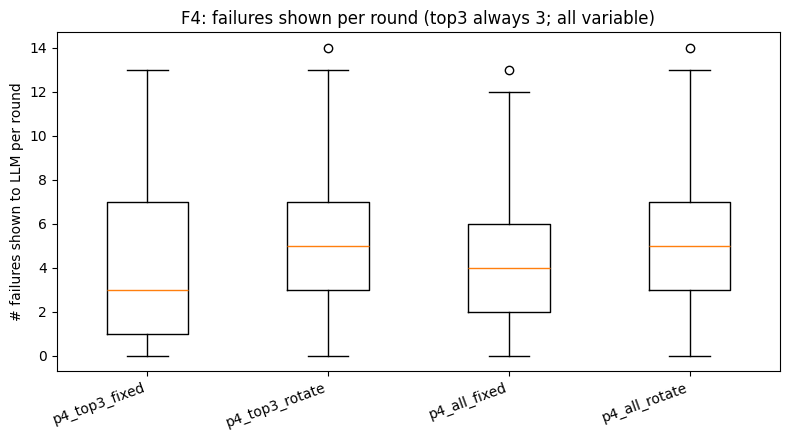

In [29]:
# ---- Cell 4: F4 failures-shown distribution per P4 method ----
# CLAIM: what the LLM 'sees' each round. p4_top3 always shows 3;
#        p4_all shows variable counts (<= correction_n).
# DATA : results/run_*/<P4-method>/results/compression_log.csv (n_failures_observed)
# USES : paper_data.compression_dataframe.
cdf = paper_data.compression_dataframe()
if cdf.empty:
    print('No compression_log.csv on disk yet.')
else:
    data = [cdf[cdf.method == m]['n_failures_observed'].values for m in paper_data.P4_METHODS]
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.boxplot(data, showfliers=True, vert=True)
    ax.set_xticks(range(1, len(paper_data.P4_METHODS) + 1))
    ax.set_xticklabels(list(paper_data.P4_METHODS), rotation=20, ha='right')
    ax.set_ylabel('# failures shown to LLM per round')
    ax.set_title('F4: failures shown per round (top3 always 3; all variable)')
    fig.tight_layout()
    paper_data.save_figure(fig, 'F4_failures_shown_per_round')


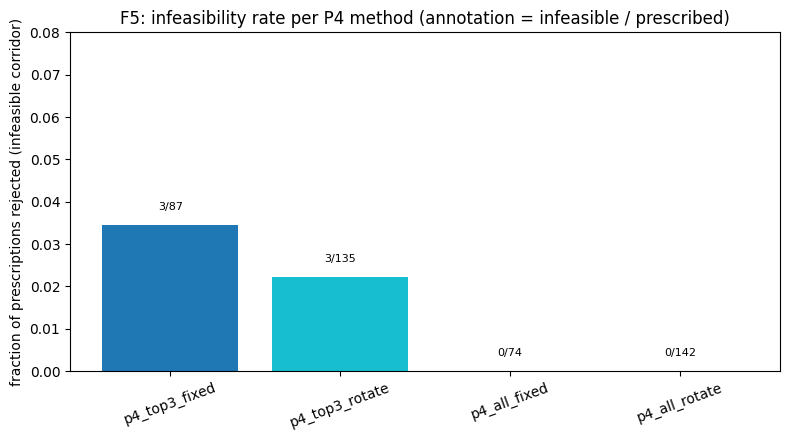

In [30]:
# ---- Cell 5: F5 corridor infeasibility rate ----
# CLAIM: how reliably the LLM-prescribed corridor passes the feasibility checker.
# DATA : results/run_*/<P4-method>/results/compression_log.csv
# USES : paper_data.compression_dataframe.
cdf = paper_data.compression_dataframe()
if cdf.empty:
    print('No compression_log.csv on disk yet.')
else:
    rates = []
    for m in paper_data.P4_METHODS:
        sub = cdf[cdf.method == m]
        prescribed = int(sub['n_layouts_prescribed'].sum())
        infeas = int(sub['n_corridor_infeasible'].sum())
        rates.append({'method': m, 'rate': infeas / max(1, prescribed),
                      'infeas': infeas, 'prescribed': prescribed})
    rdf = pd.DataFrame(rates)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(rdf['method'], rdf['rate'],
           color=['tab:blue','tab:cyan','tab:purple','tab:brown'])
    for i, row in rdf.iterrows():
        ax.text(i, row['rate'] + 0.003, f"{int(row['infeas'])}/{int(row['prescribed'])}",
                ha='center', va='bottom', fontsize=8)
    ax.set_ylim(0, max(0.08, rdf['rate'].max() * 1.4) or 0.08)
    ax.set_ylabel('fraction of prescriptions rejected (infeasible corridor)')
    ax.set_title('F5: infeasibility rate per P4 method (annotation = infeasible / prescribed)')
    ax.tick_params(axis='x', labelrotation=20)
    fig.tight_layout()
    paper_data.save_figure(fig, 'F5_infeasibility_rate')


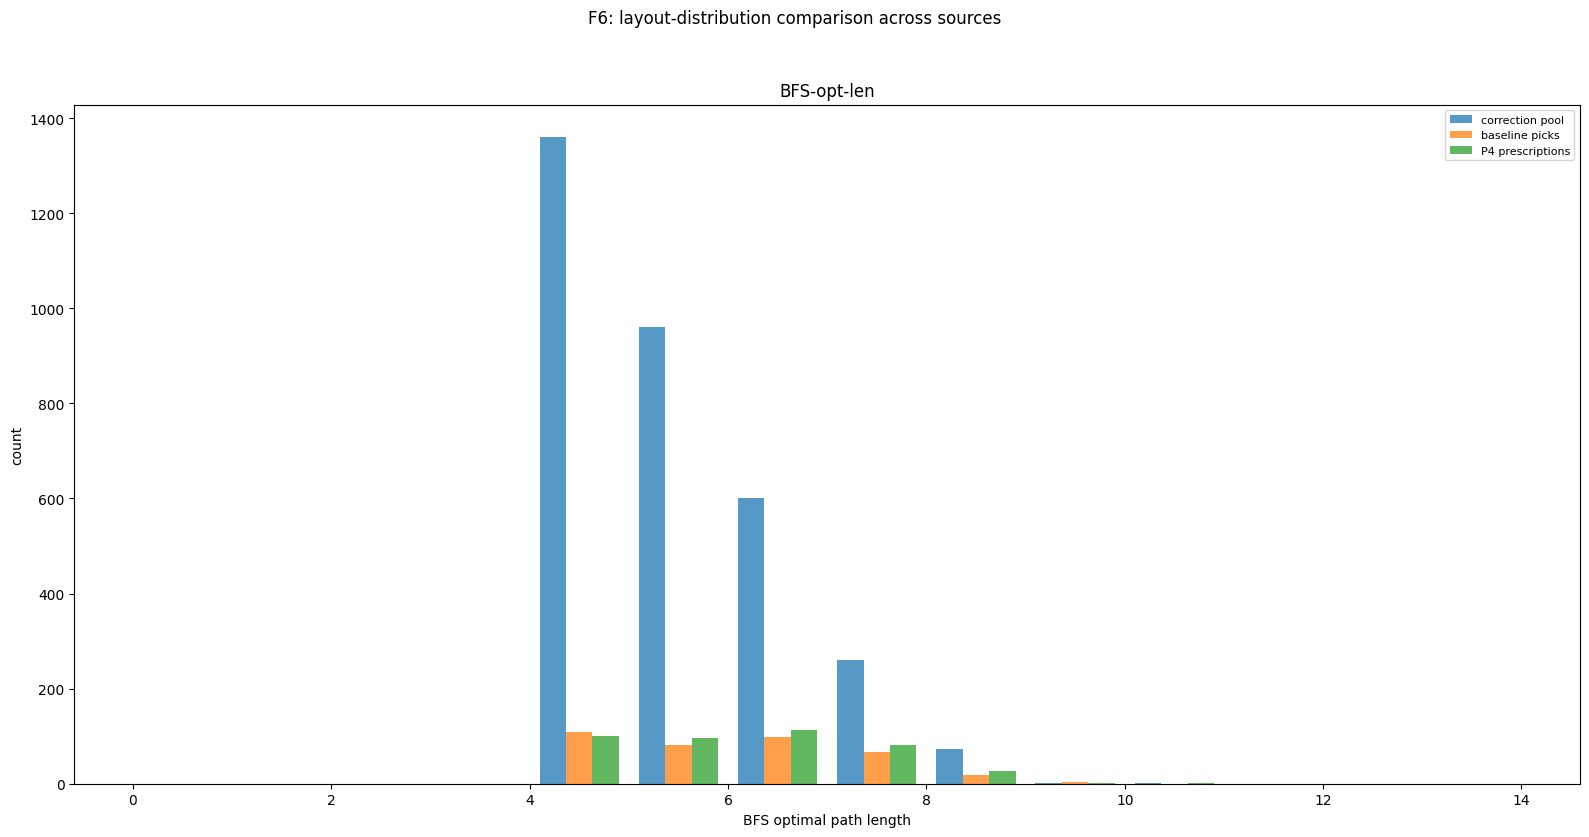

In [13]:
# ---- Cell 6: F6 layout-distribution histograms ----
# CLAIM: baselines and P4 cover different regions of the layout space
#        than the raw correction pool.
# DATA : shared/*correction_layouts.yaml (pool) + prescribed_loss.json (picks).
# USES : paper_data.iter_correction_pool_layouts, iter_prescribed_losses,
#        compute_toughness  (`expert` lazy-loaded on first call).
pool_feats, baseline_feats, p4_feats = [], [], []
for entry in paper_data.iter_correction_pool_layouts():
    pool_feats.extend(paper_data.compute_toughness(l) for l in entry['layouts'])
for m in paper_data.BASELINE_METHODS:
    for r in paper_data.iter_prescribed_losses(m):
        if r['layout']:
            baseline_feats.append(paper_data.compute_toughness(r['layout']))
for m in paper_data.P4_METHODS:
    for r in paper_data.iter_prescribed_losses(m):
        if r['layout']:
            p4_feats.append(paper_data.compute_toughness(r['layout']))

if not (pool_feats or baseline_feats or p4_feats):
    print('No layouts on disk yet.')
else:
    bfs_pool = [t['bfs_opt_len'] for t in pool_feats if t['bfs_opt_len'] > 0]
    bfs_base = [t['bfs_opt_len'] for t in baseline_feats if t['bfs_opt_len'] > 0]
    bfs_p4   = [t['bfs_opt_len'] for t in p4_feats if t['bfs_opt_len'] > 0]
    fires_pool = [t['n_fires'] for t in pool_feats]
    fires_base = [t['n_fires'] for t in baseline_feats]
    fires_p4   = [t['n_fires'] for t in p4_feats]

    fig, axes = plt.subplots(1, 1, figsize=(16, 8.5))
    axes.hist([bfs_pool, bfs_base, bfs_p4], bins=range(0, 15),
                 label=['correction pool', 'baseline picks', 'P4 prescriptions'],
                 alpha=0.75)
    axes.set_xlabel('BFS optimal path length'); axes.set_ylabel('count')
    axes.set_title('BFS-opt-len'); axes.legend(fontsize=8)
    # axes[1].hist([fires_pool, fires_base, fires_p4], bins=range(0, 8),
    #              label=['correction pool', 'baseline picks', 'P4 prescriptions'],
    #              alpha=0.75)
    # axes[1].set_xlabel('# fire cells per layout')
    # axes[1].set_title('Fire count'); axes[1].legend(fontsize=8)
    fig.suptitle('F6: layout-distribution comparison across sources', fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    paper_data.save_figure(fig, 'F6_layout_distribution')


In [32]:
# ---- Cell 7: F7 qualitative maze gallery ----
# CLAIM: a paper reader can visually verify P4 prescribes sensible corridors.
# DATA : results/run_*/<P4-method>/results/round_*/p4_analysis/recommended_layouts.json
# USES : paper_data.iter_p4_prescriptions, render_gallery
#        (`nb_helpers._layout_rgb` lazy-loaded on first call).
GALLERY_PER_METHOD = 2  # 2 per method x 4 P4 methods = 8 panels
items = []
for m in paper_data.P4_METHODS:
    seen = 0
    for r in paper_data.iter_p4_prescriptions(m):
        if seen >= GALLERY_PER_METHOD:
            break
        lay = r['layout']
        if not lay or not lay.get('steps'):
            continue
        items.append({
            'layout': lay,
            'title': f"{m}\nrun {r['run']} round {r['round']}",
            'corridor_steps': lay.get('steps'),
        })
        seen += 1

if not items:
    print('No P4 prescriptions on disk yet.')
else:
    fig = paper_data.render_gallery(
        items, ncols=4, panel_size=2.6,
        suptitle='F7: representative P4 prescriptions  (start=blue, goal=green, fires=red, corridor=orange)',
    )
    paper_data.save_figure(fig, 'F7_qualitative_gallery')


In [33]:
# ---- Cell 8: F8 recommendation evolution over rounds ----
# CLAIM: the LLM's recommendations evolve as the policy improves.
# DATA : recommended_layouts.json across rounds + compute_toughness.
# USES : paper_data.iter_p4_prescriptions, compute_toughness.
colors = {'p4_top3_fixed': 'tab:blue', 'p4_top3_rotate': 'tab:cyan',
          'p4_all_fixed': 'tab:purple', 'p4_all_rotate': 'tab:brown'}
fig, ax = plt.subplots(figsize=(9, 4.5))
any_pts = False
for m in paper_data.P4_METHODS:
    xs, ys = [], []
    for r in paper_data.iter_p4_prescriptions(m):
        t = paper_data.compute_toughness(r['layout'] or {})
        if t['bfs_opt_len'] > 0:
            xs.append(r['round']); ys.append(t['bfs_opt_len'])
    if xs:
        ax.scatter(xs, ys, s=18, alpha=0.7, color=colors.get(m), label=m)
        any_pts = True
if not any_pts:
    print('No P4 prescriptions with valid BFS on disk yet.')
else:
    ax.set_xlabel('training round')
    ax.set_ylabel('BFS optimal path length of prescribed layout')
    ax.set_title('F8: P4 recommendation toughness vs round')
    ax.legend(fontsize=8)
    fig.tight_layout()
    paper_data.save_figure(fig, 'F8_recommendation_evolution')


In [34]:
# ---- Cell 9: F9 per-run timeline (one representative run) ----
# CLAIM: how a single run unfolds method-by-method.
# DATA : results/run_<RUN>/<method>/results/learning_curve.json
# USES : direct JSON read + matplotlib.
# Pick a representative run: by default the LATEST run on disk. Override
# manually (e.g. RUN = 103) if you want a specific one.
RUN = paper_data.available_runs()[-1] if paper_data.available_runs() else None
if RUN is None:
    print('No runs on disk yet.')
else:
    fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
    for m in paper_data.METHODS:
        p = pathlib.Path(paper_data.RESULTS_ROOT) / f'run_{RUN}' / m / 'results' / 'learning_curve.json'
        if not p.exists():
            continue
        history = (json.load(open(p)).get('history') or [])
        if not history:
            continue
        rounds = [h['round'] for h in history]
        heldout = [h.get('heldout_sr') for h in history]
        corr = [h.get('correction_sr') for h in history]
        axes[0].plot(rounds, heldout, marker='o', ms=3, lw=1.2, label=m)
        axes[1].plot(rounds, [c if c is not None else float('nan') for c in corr],
                     marker='o', ms=3, lw=1.2, label=m)
    axes[0].set_ylabel('held-out SR'); axes[0].set_ylim(0, 1.05)
    axes[1].set_ylabel('correction-pool SR'); axes[1].set_xlabel('round'); axes[1].set_ylim(0, 1.05)
    axes[0].set_title(f'F9: per-method timeline for run {RUN}')
    axes[0].legend(fontsize=7, ncol=2, loc='lower right')
    fig.tight_layout()
    paper_data.save_figure(fig, f'F9_per_run_timeline_run_{RUN}')


In [35]:
# ---- Cell 10: T2 compression + system table per P4 method ----
# CLAIM: aggregate P4 numbers (compression, infeasibility, info-gain mean).
# DATA : results/run_*/<P4-method>/results/compression_log.csv
# USES : paper_data.compression_dataframe + save_table.
cdf = paper_data.compression_dataframe()
if cdf.empty:
    print('No compression_log.csv on disk yet.')
else:
    agg = cdf.groupby('method', as_index=False).agg(
        n_rounds=('round', 'count'),
        avg_failures_shown=('n_failures_observed', 'mean'),
        avg_prescribed=('n_layouts_prescribed', 'mean'),
        avg_compression=('compression_ratio', 'mean'),
        infeas_total=('n_corridor_infeasible', 'sum'),
        n_demos_total=('n_demos_collected', 'sum'),
        prescribed_loss_mean=('prescribed_loss_mean', 'mean'),
    ).round(3)
    agg['method'] = pd.Categorical(agg['method'], categories=list(paper_data.P4_METHODS), ordered=True)
    agg = agg.sort_values('method').reset_index(drop=True)
    display(agg)
    paths = paper_data.save_table(
        agg, 'T2_compression_system',
        caption='T2: per-P4-method aggregate compression, infeasibility, and info-gain.',
    )
    print('wrote', paths)


,method,n_rounds,avg_failures_shown,avg_prescribed,avg_compression,infeas_total,n_demos_total,prescribed_loss_mean
0,p4_top3_fixed,92,4.174,0.946,4.071,3,79,2.285
1,p4_top3_rotate,131,5.427,1.031,5.260,3,126,3.235
2,p4_all_fixed,83,4.289,0.892,4.271,0,73,2.015
3,p4_all_rotate,145,5.234,0.979,5.203,0,140,2.673


wrote (PosixPath('/weka/s226137394/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/pool_x_selector/results/aggregate/figures/paper/T2_compression_system.md'), PosixPath('/weka/s226137394/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/pool_x_selector/results/aggregate/figures/paper/T2_compression_system.tex'))
